In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [2]:
DATA_PATH = "../data/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df = df.rename(columns={
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature",
    "Process temperature [K]": "process_temperature",
    "Rotational speed [rpm]": "rotational_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "machine_failure"
})

In [4]:
df["temperature_difference"] = (
    df["process_temperature"]
    - df["air_temperature"]
)

In [5]:
df["mechanical_power"] = (
    df["torque"]
    * df["rotational_speed"]
    * (2 * np.pi / 60)
)

In [6]:
df["wear_torque_interaction"] = (
    df["tool_wear"]
    * df["torque"]
)

In [7]:
display(
    df[
        [
            "air_temperature",
            "process_temperature",
            "temperature_difference",
            "rotational_speed",
            "torque",
            "mechanical_power",
            "tool_wear",
            "wear_torque_interaction",
            "machine_failure"
        ]
    ].head()
)

,air_temperature,process_temperature,temperature_difference,rotational_speed,torque,mechanical_power,tool_wear,wear_torque_interaction,machine_failure
0,298.1,308.6,10.5,1551,42.8,6951.590560,0,0.0,0
1,298.2,308.7,10.5,1408,46.3,6826.722724,3,138.9,0
2,298.1,308.5,10.4,1498,49.4,7749.387543,5,247.0,0
3,298.2,308.6,10.4,1433,39.5,5927.504659,7,276.5,0
4,298.2,308.7,10.5,1408,40.0,5897.816608,9,360.0,0


In [11]:
features = [
    "type",
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
    "temperature_difference",
    "mechanical_power",
    "wear_torque_interaction"
]

target = "machine_failure"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 9)
y shape: (10000,)


In [12]:
required_columns = [
    "type",
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
    "machine_failure"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

print("All required columns are available.")

All required columns are available.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining failure rate:")
print(y_train.mean())

print("\nTesting failure rate:")
print(y_test.mean())

Training samples: 8000
Testing samples : 2000

Training failure rate:
0.033875

Testing failure rate:
0.034


In [14]:
categorical_features = [
    "type"
]

numerical_features = [
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
    "temperature_difference",
    "mechanical_power",
    "wear_torque_interaction"
]

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [16]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

In [17]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            logistic_model
        )
    ]
)

In [18]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [19]:
y_pred = logistic_pipeline.predict(X_test)

In [20]:
y_probability = (
    logistic_pipeline
    .predict_proba(X_test)[:, 1]
)

In [21]:
print(y_probability[:10])

[0.96276593 0.34870517 0.56524041 0.0071165  0.85121377 0.58055101
 0.67089481 0.0516197  0.01430063 0.28637071]


In [22]:
def risk_level(probability):

    if probability < 0.30:
        return "LOW"

    elif probability < 0.70:
        return "MEDIUM"

    else:
        return "HIGH"

In [23]:
risk_labels = [
    risk_level(p)
    for p in y_probability
]

print(risk_labels[:20])

['HIGH', 'MEDIUM', 'MEDIUM', 'LOW', 'HIGH', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW', 'LOW', 'LOW', 'MEDIUM', 'LOW', 'LOW', 'LOW', 'LOW', 'LOW', 'HIGH', 'LOW', 'LOW']


In [24]:
predictions = X_test.copy()

predictions["actual_failure"] = y_test.values

predictions["failure_probability"] = y_probability

predictions["predicted_failure"] = y_pred

predictions["risk_level"] = risk_labels

display(
    predictions.head(20)
)

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,temperature_difference,mechanical_power,wear_torque_interaction,actual_failure,failure_probability,predicted_failure,risk_level
2997,L,300.5,309.8,1345,62.7,153,9.3,8831.174029,9593.1,0,0.962766,1,HIGH
4871,L,303.7,312.4,1513,40.1,135,8.7,6353.483679,5413.5,0,0.348705,0,MEDIUM
3858,L,302.5,311.4,1559,37.6,209,8.9,6138.504494,7858.4,0,0.565240,1,MEDIUM
951,H,295.6,306.3,1509,35.8,60,10.7,5657.191555,2148.0,0,0.007117,0,LOW
6463,H,300.5,310.0,1358,60.4,102,9.5,8589.449418,6160.8,0,0.851214,1,HIGH
3264,H,301.3,310.1,1455,44.1,188,8.8,6719.395447,8290.8,0,0.580551,1,MEDIUM
4508,L,302.4,310.0,1426,46.6,102,7.6,6958.795279,4753.2,0,0.670895,1,MEDIUM
2100,M,299.3,309.3,1471,46.0,42,10.0,7085.966950,1932.0,0,0.051620,0,LOW
7885,L,300.7,312.3,1590,36.3,93,11.6,6044.110106,3375.9,0,0.014301,0,LOW
2421,L,298.9,308.2,2384,15.0,19,9.3,3744.778443,285.0,0,0.286371,0,LOW


In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8585


In [26]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"Precision: {precision:.4f}"
)

Precision: 0.1791


In [27]:
recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"Recall: {recall:.4f}"
)

Recall: 0.8824


In [28]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(
    f"F1 Score: {f1:.4f}"
)

F1 Score: 0.2978


In [29]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

ROC-AUC: 0.9385


In [30]:
pr_auc = average_precision_score(
    y_test,
    y_probability
)

print(
    f"PR-AUC: {pr_auc:.4f}"
)

PR-AUC: 0.4297


In [31]:
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy : 0.8585
Precision: 0.1791
Recall   : 0.8824
F1 Score : 0.2978
ROC-AUC  : 0.9385
PR-AUC   : 0.4297


In [32]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Normal",
            "Failure"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Normal       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



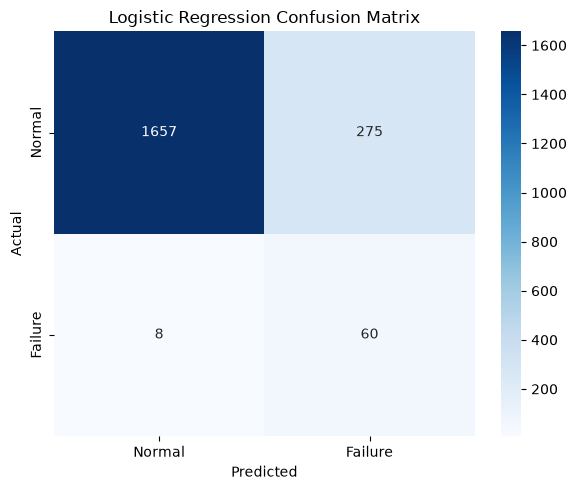

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Failure"],
    yticklabels=["Normal", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

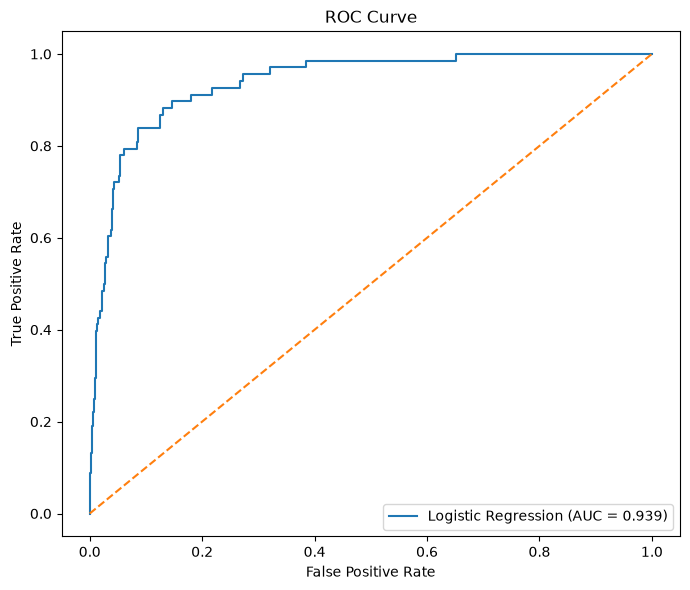

In [34]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()
plt.show()

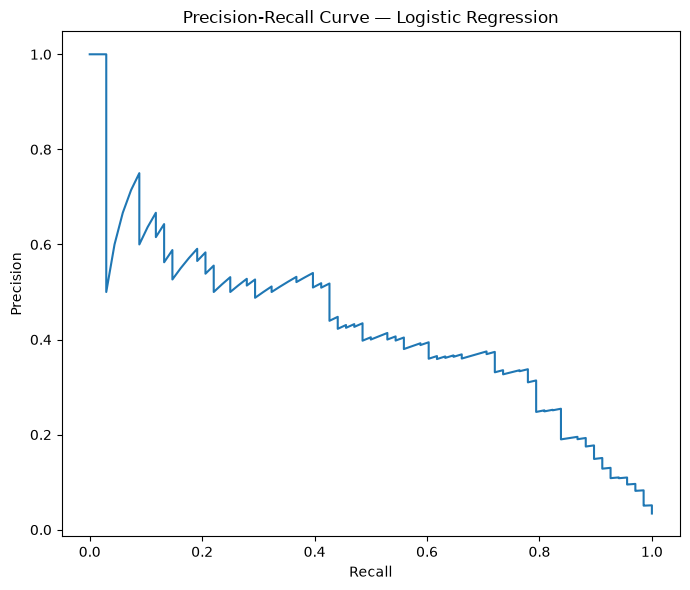

In [35]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_test,
        y_probability
    )
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve — Logistic Regression"
)

plt.tight_layout()
plt.show()

In [36]:
feature_names = (
    logistic_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_pipeline
    .named_steps["classifier"]
    .coef_[0]
)

In [37]:
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"]
    .abs()
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

display(coefficient_table)

,Feature,Coefficient,Absolute_Coefficient
3,num__torque,7.901030,7.901030
6,num__mechanical_power,-4.223100,4.223100
2,num__rotational_speed,2.473869,2.473869
4,num__tool_wear,2.341978,2.341978
7,num__wear_torque_interaction,-1.289963,1.289963
5,num__temperature_difference,-0.650626,0.650626
10,cat__type_M,-0.610302,0.610302
8,cat__type_H,-0.557163,0.557163
0,num__air_temperature,0.257719,0.257719
9,cat__type_L,-0.183161,0.183161


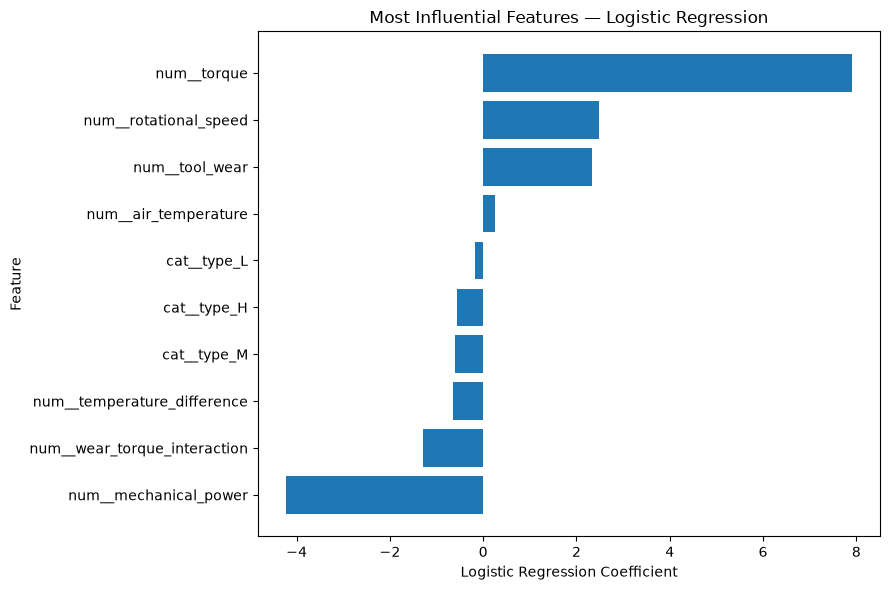

In [38]:
top_coefficients = (
    coefficient_table
    .head(10)
    .sort_values("Coefficient")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.title(
    "Most Influential Features — Logistic Regression"
)

plt.tight_layout()
plt.show()

In [39]:
new_machine = pd.DataFrame({
    "type": ["M"],
    "air_temperature": [302.0],
    "process_temperature": [312.0],
    "rotational_speed": [1400],
    "torque": [60.0],
    "tool_wear": [190]
})

In [40]:
new_machine["temperature_difference"] = (
    new_machine["process_temperature"]
    - new_machine["air_temperature"]
)

new_machine["mechanical_power"] = (
    new_machine["torque"]
    * new_machine["rotational_speed"]
    * (2 * np.pi / 60)
)

new_machine["wear_torque_interaction"] = (
    new_machine["tool_wear"]
    * new_machine["torque"]
)

In [41]:
machine_probability = (
    logistic_pipeline
    .predict_proba(new_machine)[:, 1][0]
)

machine_prediction = (
    logistic_pipeline
    .predict(new_machine)[0]
)

machine_risk = risk_level(
    machine_probability
)

print(
    f"Failure probability: "
    f"{machine_probability:.2%}"
)

print(
    f"Predicted failure: "
    f"{machine_prediction}"
)

print(
    f"Risk level: "
    f"{machine_risk}"
)

Failure probability: 84.84%
Predicted failure: 1
Risk level: HIGH


In [42]:
import joblib

In [43]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

In [44]:
joblib.dump(
    logistic_pipeline,
    "../models/logistic_regression_pipeline.joblib"
)

['../models/logistic_regression_pipeline.joblib']

In [45]:
print(
    "Model saved successfully."
)

Model saved successfully.


In [46]:
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc
}

metrics_df = pd.DataFrame(
    [metrics]
)

os.makedirs(
    "../results/metrics",
    exist_ok=True
)

metrics_df.to_csv(
    "../results/metrics/logistic_regression_metrics.csv",
    index=False
)

display(metrics_df)

,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,0.8585,0.179104,0.882353,0.297767,0.938505,0.429703


In [47]:
os.makedirs(
    "../results/predictions",
    exist_ok=True
)

predictions.to_csv(
    "../results/predictions/logistic_regression_predictions.csv",
    index=False
)